In [ ]:
import os
import tarfile

# Create target directories
os.makedirs('/content/ptc_data', exist_ok=True)
os.makedirs('/content/output', exist_ok=True)

# Unpack the dataset archive directly into the folder
with tarfile.open('/content/datasets-v2.tgz', 'r:gz') as tar:
    tar.extractall(path='/content/ptc_data')

print("Extraction complete. Directory structure initialized:")
print(os.listdir('/content/ptc_data/datasets'))

/tmp/ipykernel_425/2822678515.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content/ptc_data')


Extraction complete. Directory structure initialized:
['train-articles', 'README.md', 'train-task2-TC.labels', 'train-labels-task2-technique-classification', 'train-labels-task1-span-identification', 'dev-articles', 'train-task1-SI.labels', 'dev-task-TC-template.out']


In [ ]:
import os
import pandas as pd

# Define paths
labels_path = '/content/train-task2-TC.labels'
txt_dir = '/content/ptc_data/datasets/train-articles'

# Read unique article IDs from the labels file
df_labels = pd.read_csv(labels_path, sep='\t', header=None, names=['article_id', 'technique', 'start', 'end'])
unique_articles = set(df_labels['article_id'].astype(str))

# Check which text files actually exist in the extracted folder
existing_files = set()
if os.path.exists(txt_dir):
    for f in os.listdir(txt_dir):
        if f.startswith('article') and f.endswith('.txt'):
            art_id = f.replace('article', '').replace('.txt', '')
            existing_files.add(art_id)

# Identify missing files
missing = unique_articles - existing_files

print(f"Total unique articles required by labels: {len(unique_articles)}")
print(f"Total articles found in directory: {len(existing_files)}")
print(f"Missing articles count: {len(missing)}")

if missing:
    print(f"Missing IDs: {list(missing)}")
else:
    print("All required article text files are present and mapped successfully!")

Total unique articles required by labels: 357
Total articles found in directory: 371
Missing articles count: 0
All required article text files are present and mapped successfully!


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, f1_score, accuracy_score

# 1. Recreate the evaluation dataframe correctly (preserving the technique_true column)
# Using the exact same random_state guarantees the exact same order as your generated predictions!
df_eval_fixed = (df_all[df_all['technique_true'].isin(top_techniques)]
                 .groupby('technique_true', group_keys=False)
                 .apply(lambda s: s.sample(min(len(s), 15), random_state=42)))

df_eval_fixed = df_eval_fixed.reset_index(drop=True)

# 2. Attach the predictions that are still stored in your Colab memory
df_eval_fixed['technique_pred'] = predictions

# 3. Calculate and Output Performance Metrics
y_true = df_eval_fixed['technique_true']
y_pred = df_eval_fixed['technique_pred']

print("\n--- LOCAL QWEN 2.5 7B ZERO-SHOT EVALUATION REPORT ---")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro-F1 Score:   {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print("\nDetailed Breakdown:")
print(classification_report(y_true, y_pred, zero_division=0))

# 4. Save results
output_file = '/content/llm_local_results.csv'
df_eval_fixed.to_csv(output_file, index=False)
print(f"Saved predictions to {output_file}")


--- LOCAL QWEN 2.5 7B ZERO-SHOT EVALUATION REPORT ---
Overall Accuracy: 0.3467
Macro-F1 Score:   0.2768

Detailed Breakdown:
                           precision    recall  f1-score   support

                    Doubt       0.50      0.07      0.12        15
Exaggeration,Minimisation       0.46      0.40      0.43        15
          Loaded_Language       0.33      0.73      0.46        15
    Name_Calling,Labeling       0.64      0.47      0.54        15
                     None       0.00      0.00      0.00         0
               Repetition       0.50      0.07      0.12        15

                 accuracy                           0.35        75
                macro avg       0.41      0.29      0.28        75
             weighted avg       0.49      0.35      0.33        75

Saved predictions to /content/llm_local_results.csv


/tmp/ipykernel_425/4045775326.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda s: s.sample(min(len(s), 15), random_state=42)))


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import classification_report, f1_score, accuracy_score

# 1. Load Spans and Form Splits
labels_path = '/content/train-task2-TC.labels'
txt_dir = '/content/ptc_data/datasets/train-articles'
df_labels = pd.read_csv(labels_path, sep='\t', header=None, names=['article_id', 'technique', 'start', 'end'])

records = []
for _, row in df_labels.iterrows():
    art_id = str(row['article_id'])
    file_path = os.path.join(txt_dir, f"article{art_id}.txt")
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            full_text = f.read()
            snippet = full_text[row['start']:row['end']].replace('\n', ' ').strip()

            ctx_start = max(0, row['start'] - 60)
            ctx_end = min(len(full_text), row['end'] + 60)
            context = full_text[ctx_start:ctx_end].replace('\n', ' ').strip()

            records.append({
                'text': f"{snippet} [SEP] Context: {context}",
                'label_name': row['technique']
            })

df_all = pd.DataFrame(records)

# Filter for the top 5 classes
top_techniques = ['Loaded_Language', 'Name_Calling,Labeling', 'Repetition', 'Doubt', 'Exaggeration,Minimisation']
df_filtered = df_all[df_all['label_name'].isin(top_techniques)].copy()

label2id = {label: idx for idx, label in enumerate(top_techniques)}
id2label = {idx: label for label, idx in label2id.items()}
df_filtered['label'] = df_filtered['label_name'].map(label2id)

# Clean, warning-free sampling logic
df_test = df_filtered.groupby('label_name').sample(n=15, random_state=42)
df_train = df_filtered.drop(df_test.index)

# Group, shuffle, and extract up to 120 samples per class for training
df_train = (df_train.groupby('label_name')
            .apply(lambda x: x.sample(n=min(len(x), 120), random_state=42), include_groups=False)
            .reset_index())

print(f"Training samples: {len(df_train)} | Test samples: {len(df_test)}")

# 2. Tokenization
model_checkpoint = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=256)

ds_train = Dataset.from_pandas(df_train).map(tokenize_fn, batched=True)
ds_test = Dataset.from_pandas(df_test).map(tokenize_fn, batched=True)

# 3. Model Setup & Training
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(top_techniques),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./deberta_checkpoints",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=20,
    fp16=False, # Disabled to prevent gradient scaling crash on T4
    report_to="none"
)

# Initialize Trainer WITHOUT the deprecated tokenizer argument
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
)

print("Fine-tuning DeBERTa-v3 on T4 GPU...")
trainer.train()

# 4. Evaluation on Test Set
print("\nRunning inference on test split...")
raw_preds = trainer.predict(ds_test)
y_pred_ids = np.argmax(raw_preds.predictions, axis=1)

df_test['technique_pred'] = [id2label[i] for i in y_pred_ids]
y_true = df_test['label_name']
y_pred = df_test['technique_pred']

# 5. Output Metrics
print("\n--- SUPERVISED DEBERTA-V3 BASELINE REPORT ---")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro-F1 Score:   {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print("\nDetailed Breakdown:")
print(classification_report(y_true, y_pred, zero_division=0))

df_test.to_csv('/content/deberta_baseline_results.csv', index=False)
print("Saved baseline predictions to /content/deberta_baseline_results.csv")

Training samples: 600 | Test samples: 75


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

Fine-tuning DeBERTa-v3 on T4 GPU...


Step,Training Loss
20,1.523931
40,0.000000
60,0.000000
80,0.000000
100,0.000000



Running inference on test split...



--- SUPERVISED DEBERTA-V3 BASELINE REPORT ---
Overall Accuracy: 0.2000
Macro-F1 Score:   0.0667

Detailed Breakdown:
                           precision    recall  f1-score   support

                    Doubt       0.00      0.00      0.00        15
Exaggeration,Minimisation       0.00      0.00      0.00        15
          Loaded_Language       0.20      1.00      0.33        15
    Name_Calling,Labeling       0.00      0.00      0.00        15
               Repetition       0.00      0.00      0.00        15

                 accuracy                           0.20        75
                macro avg       0.04      0.20      0.07        75
             weighted avg       0.04      0.20      0.07        75

Saved baseline predictions to /content/deberta_baseline_results.csv


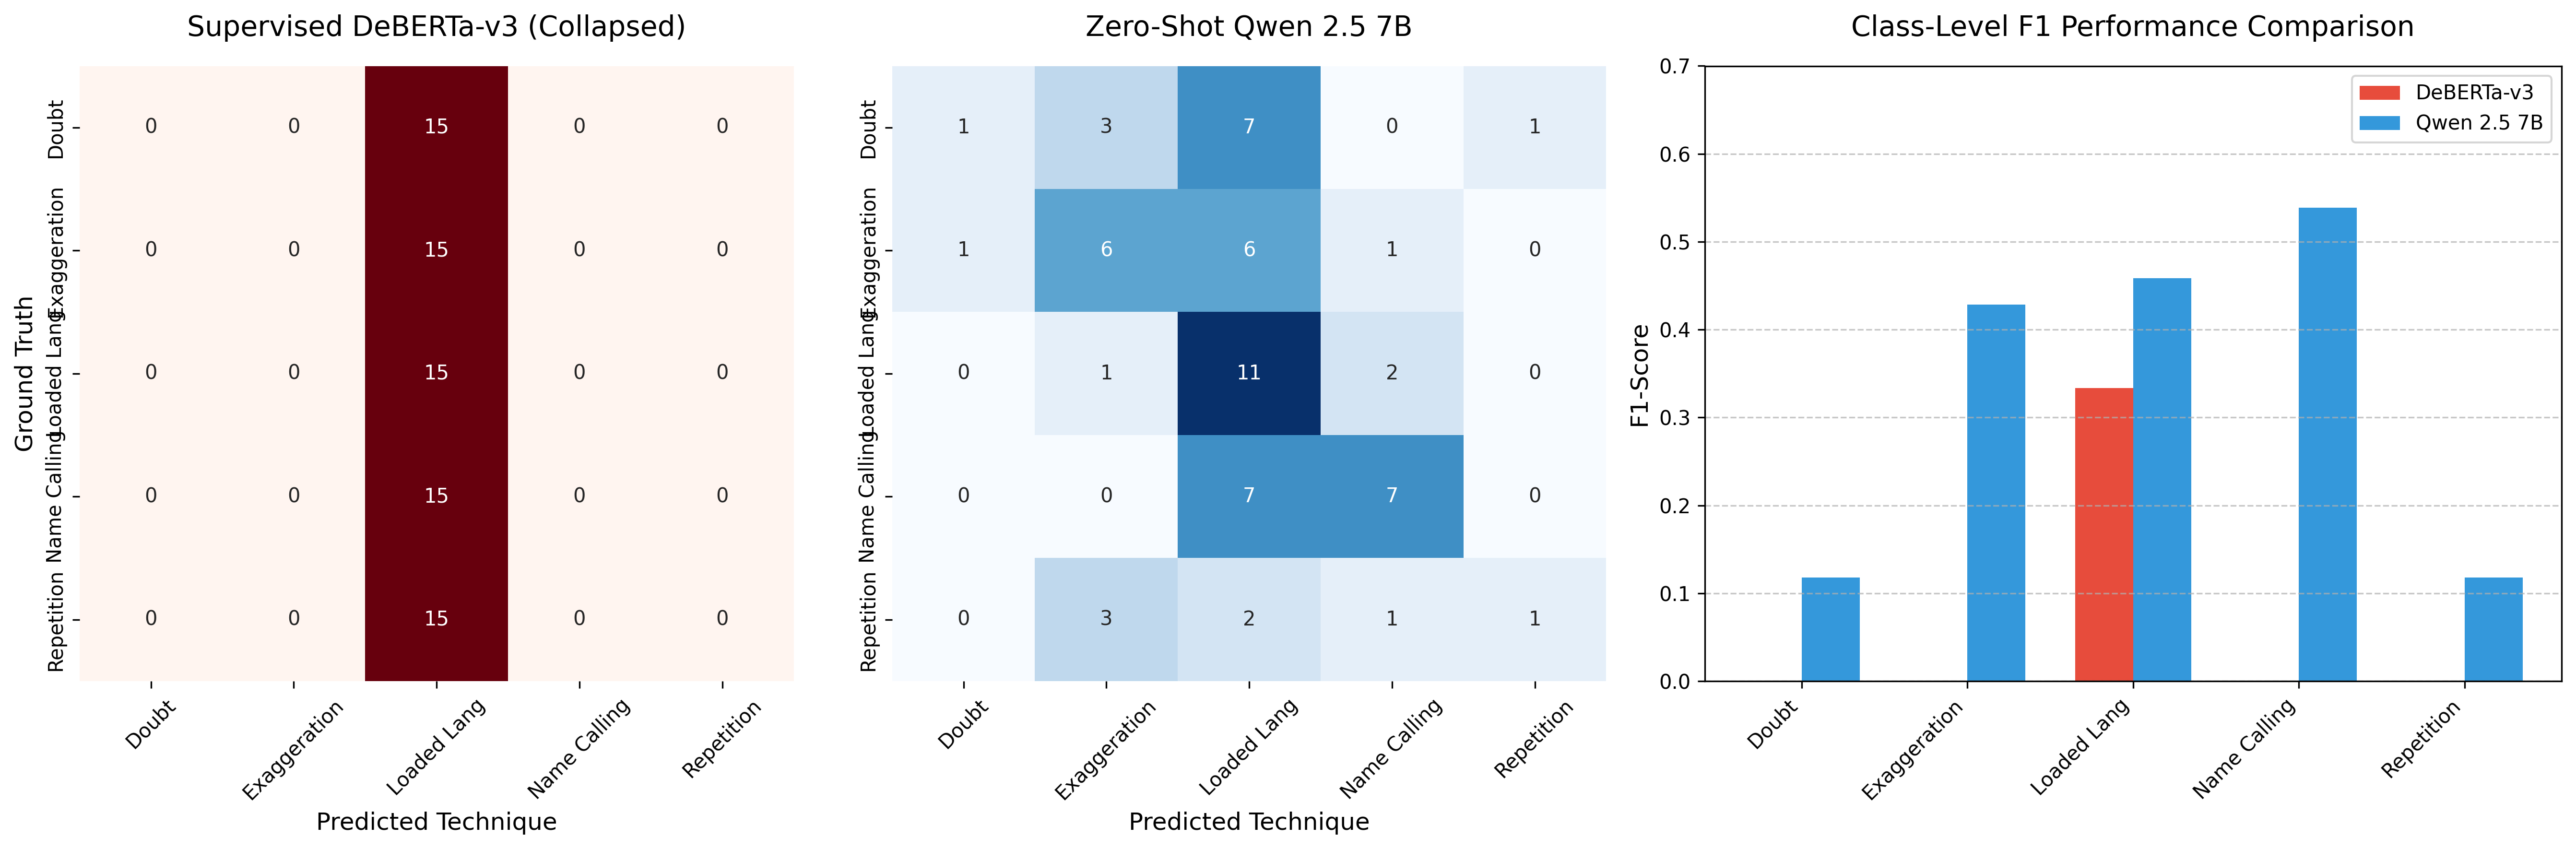

Poster graphics successfully saved to /content/poster_visualizations.pdf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# 1. Load the results and sanitize mixed data types
df_llm = pd.read_csv('/content/llm_local_results.csv')
df_deb = pd.read_csv('/content/deberta_baseline_results.csv')

df_llm['technique_true'] = df_llm['technique_true'].fillna('None').astype(str)
df_llm['technique_pred'] = df_llm['technique_pred'].fillna('None').astype(str)

df_deb['label_name'] = df_deb['label_name'].fillna('None').astype(str)
df_deb['technique_pred'] = df_deb['technique_pred'].fillna('None').astype(str)

top_techniques = ['Doubt', 'Exaggeration,Minimisation', 'Loaded_Language', 'Name_Calling,Labeling', 'Repetition']
short_labels = ['Doubt', 'Exaggeration', 'Loaded Lang', 'Name Calling', 'Repetition']

# 2. Setup Figure for DIN A1 High-Res Print (Horizontal Layout)
fig = plt.figure(figsize=(18, 6), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

# --- Subplot 1: DeBERTa Confusion Matrix ---
ax1 = fig.add_subplot(gs[0])
cm_deb = confusion_matrix(df_deb['label_name'], df_deb['technique_pred'], labels=top_techniques)
sns.heatmap(cm_deb, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax1,
            xticklabels=short_labels, yticklabels=short_labels)
ax1.set_title('Supervised DeBERTa-v3 (Collapsed)', fontsize=14, pad=15)
ax1.set_ylabel('Ground Truth', fontsize=12)
ax1.set_xlabel('Predicted Technique', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# --- Subplot 2: Qwen LLM Confusion Matrix ---
ax2 = fig.add_subplot(gs[1])
cm_llm = confusion_matrix(df_llm['technique_true'], df_llm['technique_pred'], labels=top_techniques)
sns.heatmap(cm_llm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2,
            xticklabels=short_labels, yticklabels=short_labels)
ax2.set_title('Zero-Shot Qwen 2.5 7B', fontsize=14, pad=15)
ax2.set_xlabel('Predicted Technique', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

# --- Subplot 3: Macro-F1 Comparison Bar Chart ---
ax3 = fig.add_subplot(gs[2])
f1_deb = [f1_score(df_deb['label_name'] == tech, df_deb['technique_pred'] == tech, zero_division=0) for tech in top_techniques]
f1_llm = [f1_score(df_llm['technique_true'] == tech, df_llm['technique_pred'] == tech, zero_division=0) for tech in top_techniques]

x = np.arange(len(top_techniques))
width = 0.35

ax3.bar(x - width/2, f1_deb, width, label='DeBERTa-v3', color='#e74c3c')
ax3.bar(x + width/2, f1_llm, width, label='Qwen 2.5 7B', color='#3498db')

ax3.set_ylabel('F1-Score', fontsize=12)
ax3.set_title('Class-Level F1 Performance Comparison', fontsize=14, pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(short_labels, rotation=45, ha="right")
ax3.legend()
ax3.set_ylim(0, 0.7)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/content/poster_visualizations.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Poster graphics successfully saved to /content/poster_visualizations.pdf")

In [ ]:
import pandas as pd

# 1. Load the local LLM results
df = pd.read_csv('/content/llm_local_results.csv')

# 2. Filter for cases where the model falsely predicted 'Loaded_Language'
false_positives = df[(df['technique_true'] != df['technique_pred']) &
                     (df['technique_pred'] == 'Loaded_Language')]

print(f"Total False Positives for 'Loaded_Language': {len(false_positives)}\n")
print("--- ERROR ANALYSIS SAMPLES ---")

# 3. Display 3 random examples for your poster
for idx, row in false_positives.sample(n=min(3, len(false_positives)), random_state=42).iterrows():
    print(f"Ground Truth : {row['technique_true']}")
    print(f"Predicted    : {row['technique_pred']}")
    print(f"Snippet      : \"{row['snippet']}\"")
    print(f"Context      : \"{row['context']}\"")
    print("-" * 80)

Total False Positives for 'Loaded_Language': 22

--- ERROR ANALYSIS SAMPLES ---
Ground Truth : Doubt
Predicted    : Loaded_Language
Snippet      : "You’re wrong, Mr. President"
Context      : "orney General Jeff Sessions has a message for Donald Trump: You’re wrong, Mr. President. Sessions long has been one of Trump’s favorite pinatas, of"
--------------------------------------------------------------------------------
Ground Truth : Name_Calling,Labeling
Predicted    : Loaded_Language
Snippet      : "those who are counterfeits"
Context      : "ll who the genuine Christians are that are in the fight and those who are counterfeits. When the church and the world can jog comfortably along to"
--------------------------------------------------------------------------------
Ground Truth : Exaggeration,Minimisation
Predicted    : Loaded_Language
Snippet      : "No Justice for Kate Steinle"
Context      : "No Justice for Kate Steinle  A San Francisco jury on Thursday found Jose Ines Garcia Za